In [1]:
%env ANYWIDGET_HMR=1
from guidepost import Guidepost, Campsite
from IPython.display import HTML
import json

gp = Guidepost()
cs = Campsite()

env: ANYWIDGET_HMR=1


In [6]:
# cs.test_server()
hypothesis = 'E[failure_indicator | utilization < 0.3 ] > E[failure_indicator | utilization > 0.8 ] (gpu = true)'
natural_language = 'Jobs requesting GPUs but exhibiting low GPU utilization are more likely to fail than high-utilization GPU jobs.'
# HTML((cs.test_parser(hypothesis, natural_language)))
response = json.loads(cs.test_parser(hypothesis, natural_language))
print(json.dumps(response['parsed'], indent=2))
print(json.dumps(response['violations'], indent=2))

event.comparator :{'value': '>', 'confidence': 0.72, 'rationale': "The hypothesis states that the failure probability for jobs with low GPU utilization is higher than that for high-utilization GPU jobs (P(fail|low) > P(fail|high)), which corresponds to a 'greater than' relation between the two groups' failure likelihoods."}
>
event.reference :{'value': None, 'confidence': 0.6, 'rationale': "The hypothesis contrasts 'low GPU utilization' with 'high-utilization' without specifying a numeric threshold or explicit reference value."}
None
event.form :{'value': 'conditioned', 'confidence': 0.72, 'rationale': 'The hypothesis compares two subgroups defined by GPU utilization levels (low vs high) and asserts a difference in failure probability, i.e., a conditional comparison.'}
conditioned
quantity.signature :{'value': 'contrast', 'confidence': 0.9, 'rationale': 'It asserts a difference in failure likelihood between two groups (low GPU utilization vs high utilization), i.e., a between-group con

127.0.0.1 - - [06/Feb/2026 15:55:43] "POST /parse HTTP/1.1" 200 -


quantity.uncertainty_target :{'value': None, 'confidence': 0.0, 'rationale': 'No uncertainty is mentioned in the hypothesis; it states a comparative likelihood without hedging.'}
None
{
  "event": {
    "comparator": ">",
    "predicate": {
      "attr": "gpu",
      "comparator": "=",
      "kind": "comparison",
      "lhs": null,
      "rhs": null,
      "type": "predicate",
      "value": true
    },
    "quantity": {
      "distribution": "Distribution",
      "estimand": {
        "attr": "failure_indicator",
        "predicate": {
          "attr": "utilization",
          "comparator": "<",
          "kind": "comparison",
          "lhs": null,
          "rhs": null,
          "type": "predicate",
          "value": 0.3
        },
        "type": "expectation"
      },
      "type": "rv"
    },
    "referent": {
      "distribution": "Distribution",
      "estimand": {
        "attr": "failure_indicator",
        "predicate": {
          "attr": "utilization",
          "compara

In [4]:
import pandas as pd
# jobs_data = pd.read_parquet("../data/test_data_med.parquet")
# jobs_data = pd.read_parquet("../data/kestrel_data_2024_01_28_subsample.parquet")
# jobs_data = pd.read_csv("../data/ANL-ALCF-DJC-THETA_20240101_20241231.csv.gz", compression='gzip')
jobs_data = pd.read_csv("../data/ANL-ALCF-DJC-POLARIS_20250101_20251231.csv.gz", compression='gzip')
df = pd.read_csv("../data/ANL-ALCF-MACHINESTATUS-POLARIS_20250101_20251231.csv.gz", compression='gzip')

# jobs_data
# gp.records = jobs_data
cs.records = jobs_data

/tmp/ipykernel_762277/924531520.py:5: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  jobs_data = pd.read_csv("../data/ANL-ALCF-DJC-POLARIS_20250101_20251231.csv.gz", compression='gzip')


In [5]:
jobs_data.columns
# jobs_data['Y'] = (jobs_data["EXIT_STATUS"] == 0).astype(int)
# jobs_data['LOCATION'].unique()

Index(['JOB_NAME', 'COBALT_JOBID', 'MACHINE_NAME', 'QUEUED_TIMESTAMP',
       'QUEUED_DATE_ID', 'START_TIMESTAMP', 'START_DATE_ID', 'END_TIMESTAMP',
       'END_DATE_ID', 'USERNAME_GENID', 'PROJECT_NAME_GENID',
       'ALLOCATION_AWARD_CATEGORY', 'QUEUE_NAME', 'WALLTIME_SECONDS',
       'RUNTIME_SECONDS', 'NODES_USED', 'NODES_REQUESTED', 'CORES_USED',
       'CORES_REQUESTED', 'LOCATION', 'EXIT_STATUS', 'ELIGIBLE_WAIT_SECONDS',
       'ELIGIBLE_WAIT_FACTOR', 'QUEUED_WAIT_SECONDS', 'QUEUED_WAIT_FACTOR',
       'REQUESTED_CORE_HOURS', 'USED_CORE_HOURS',
       'CAPABILITY_USAGE_CORE_HOURS', 'NONCAPABILITY_USAGE_CORE_HOURS',
       'BUCKETS3_A_USAGE_CORE_HOURS', 'BUCKETS3_B_USAGE_CORE_HOURS',
       'BUCKETS3_C_USAGE_CORE_HOURS', 'MACHINE_PARTITION', 'EXIT_CODE', 'MODE',
       'RESID', 'DATA_LOAD_STATUS', 'CAPABILITY', 'SIZE_BUCKETS3',
       'PERCENTILE', 'NUM_TASKS_SUBBLOCK', 'NUM_TASKS_CONSECUTIVE',
       'NUM_TASKS_MULTILOCATION', 'NUM_TASKS_SINGLE', 'COBALT_NUM_TASKS',
       'IS_S

In [6]:
cs

Campsite()

In [11]:
# !pip install altair
# !pip install "vegafusion>=2.0.3"
!pip install "vl-convert-python>=1.8.0"
import pandas as pd
import numpy as np
import altair as alt
alt.data_transformers.enable("vegafusion")

def visualize_over_requesting(df, alpha=0.05, max_bins=60):
    """
    Visualize the primary quantity of interest for the over-requesting hypothesis.

    Primary quantity of interest:
      R_i = REQUESTED_CORE_HOURS_i / USED_CORE_HOURS_i
    Inclusion (per job):
      - REQUESTED_CORE_HOURS > 0
      - USED_CORE_HOURS > 0
      - END_TIMESTAMP is not null
      - EXIT_STATUS = 0 (completed)

    Hypotheses:
      H0: E[log(R_i)] = 0
      H1: E[log(R_i)] > 0  (over-requesting)

    Visualization:
      - Histogram of log(R_i) with bins, overlaid with a vertical line at log(R_i)=0 (R=1)
      - Title annotates sample size, mean log(R), 95% CI for mean(log(R)),
        and a one-sided p-value for H1: E[log(R)] > 0 (if SciPy is available)

    Returns:
      An Altair Chart object (vega-lite spec) that can be rendered with .display() in Jupyter
      or chart.show()/chart.save as appropriate in your environment.
    """
    # Basic filtering per the refinement rules
    mask = (
        (df.get('REQUESTED_CORE_HOURS', pd.Series(dtype=float)) > 0) &
        (df.get('USED_CORE_HOURS', pd.Series(dtype=float)) > 0) &
        df.get('END_TIMESTAMP', pd.Series(dtype='float')).notna() &
        (df.get('EXIT_STATUS', pd.Series(dtype=float)) == 0)
    )
    df_valid = df.loc[mask].copy()
    if df_valid.shape[0] < 2:
        # Not enough data to test; return a simple placeholder chart
        placeholder = pd.DataFrame({'x': [0]})
        chart = alt.Chart(placeholder).mark_text().encode(text=alt.datum('No data available for the required criteria.'))
        chart = chart.properties(title="Primary test: insufficient data after inclusion criteria.")
        return chart

    # Compute R_i and log(R_i)
    df_valid['R'] = df_valid['REQUESTED_CORE_HOURS'] / df_valid['USED_CORE_HOURS']
    df_valid = df_valid[df_valid['R'] > 0]  # safety net (should already be >0 due to inclusion)
    df_valid['log_R'] = np.log(df_valid['R'])

    log_R = df_valid['log_R'].values
    n = log_R.size

    # Attempt to compute one-sided test on mean(log_R) > 0
    p_one_sided = None
    mean_logR = float(np.mean(log_R))
    se = float(np.std(log_R, ddof=1)) / np.sqrt(n) if n > 1 else np.nan  # standard error of the mean
    t_stat = np.nan
    ci_low = ci_high = np.nan

    # Compute p-value and CI if SciPy is available
    try:
        from scipy.stats import t as tdist
        if n > 1 and se > 0:
            t_stat = (mean_logR - 0.0) / se
            # one-sided p-value for H1: mean(log_R) > 0
            if t_stat > 0:
                p_one_sided = float(1.0 - tdist.cdf(t_stat, df=n-1))
            else:
                p_one_sided = float(1.0)  # no evidence in the >0 direction
            # 95% CI for the mean
            t_crit = tdist.ppf(1 - alpha/2, df=n-1)
            ci_low = mean_logR - t_crit * se
            ci_high = mean_logR + t_crit * se
        else:
            t_stat = np.nan
    except Exception:
        # SciPy not available or calculation failed
        p_one_sided = None
        t_stat = None
        ci_low = ci_high = np.nan

    # Build histogram of log_R
    hist = alt.Chart(df_valid).mark_bar().encode(
        x=alt.X('log_R:Q', bin=alt.Bin(maxbins=max_bins), title='log(R) = log(REQUESTED/USED)'),
        y=alt.Y('count()', title='Number of jobs')
    ).properties(width=700, height=300)

    # Overlay a vertical line at log_R = 0 (R = 1)
    vertical_line_df = pd.DataFrame({
        'log_R': [0, 0],
        'count': [0, df_valid.shape[0]]
    })
    vline = alt.Chart(vertical_line_df).mark_line(color='red', strokeWidth=2).encode(
        x='log_R:Q',
        y='count:Q'
    )

    # Build a chart title that reports the test statistics (if available)
    title_parts = [
        f"Primary test: E[log(R)] > 0 (n={n})"
    ]
    if not np.isnan(mean_logR) and not np.isnan(ci_low) and not np.isnan(ci_high):
        title_parts.append(f"mean(log(R))={mean_logR:.4f}, 95% CI=[{ci_low:.4f}, {ci_high:.4f}]")
        if p_one_sided is not None:
            title_parts.append(f"p(one-sided) ≈ {p_one_sided:.3g}")
    title_text = " | ".join(title_parts)

    chart = alt.layer(hist, vline).properties(title=title_text, width=700, height=350)

    return chart
    
chart = visualize_over_requesting(jobs_data)
chart


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 10.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


alt.LayerChart(...)


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


/tmp/ipykernel_724614/3146007852.py:193: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


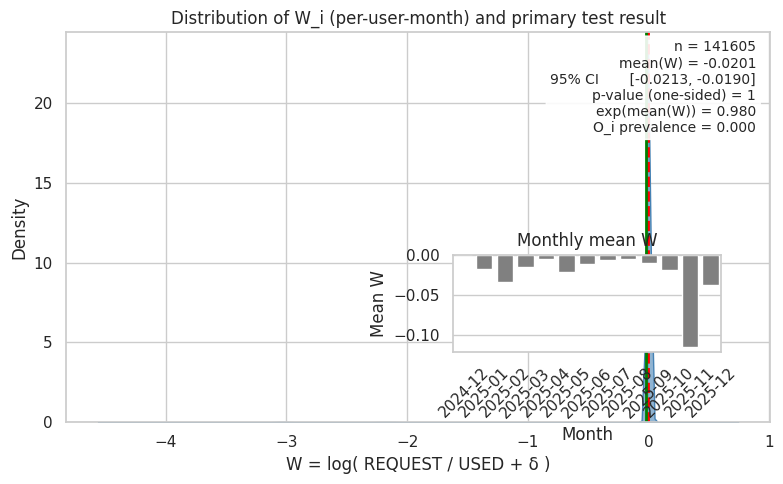

In [9]:
!pip install scipy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def visualize_over_request_hypothesis(
    df,
    req_col='REQUESTED_CORE_HOURS',
    used_cols=None,
    delta=1e-6,
    winsor_pct=0.01,
    date_col='START_TIMESTAMP',
    include_primary_filter=True,
    date_col_format='datetime',
    min_obs=30,
    random_seed=0
):
    """
    Create a single visualization to test the primary hypothesis:
      E[W_i] > 0 where W_i = log( REQUEST_i / ( USED_i + δ ) ),
    for per-user-month observations.

    Parameters
    - df: pandas DataFrame containing the data.
    - req_col: name of the requested core hours column (default 'REQUESTED_CORE_HOURS').
    - used_cols: list or tuple of column names to compute USED_TOTAL.
                 If None, attempts to use USED_CORE_HOURS or CAPABILITY & NONCAPABILITY sums.
    - delta: small constant added to denominator to avoid log(0).
    - winsor_pct: fraction for winsorizing REQUEST and USED totals (e.g., 0.01 for 1st/99th percentiles).
    - date_col: name of date column to derive monthly trend inset (optional).
    - include_primary_filter: if True, apply END_STATUS=0 and EXIT_CODE=0 filter when columns exist.
    - date_col_format: 'datetime' or 'string'; if 'datetime', will parse to datetime.
    - min_obs: minimum number of observations required to produce the visualization.
    - random_seed: seed for any randomness (if sampling is used).
    
    Returns
    - fig: matplotlib Figure object containing the visualization.
    - df_out: a DataFrame after processing, containing computed columns like USED_TOTAL, W, O, etc.
    - stats: dict with mean(W), 95% CI, p-value (one-sided), exp(mean(W)) as interpretability, N, and O_i prevalence.
    """

    # 1) Determine USED_TOTAL
    if used_cols is None:
        if {'CAPABILITY_USAGE_CORE_HOURS', 'NONCAPABILITY_USAGE_CORE_HOURS'}.issubset(df.columns):
            df = df.copy()
            df['USED_TOTAL'] = df['CAPABILITY_USAGE_CORE_HOURS'] + df['NONCAPABILITY_USAGE_CORE_HOURS']
        elif {'USED_CORE_HOURS'}.issubset(df.columns):
            df = df.copy()
            df['USED_TOTAL'] = df['USED_CORE_HOURS']
        else:
            raise ValueError("Could not determine USED_TOTAL: supply used_cols or ensure USED_CORE_HOURS exists.")
    else:
        # sum the provided used_cols
        df = df.copy()
        if len(used_cols) == 1:
            df['USED_TOTAL'] = df[used_cols[0]]
        elif len(used_cols) >= 2:
            df['USED_TOTAL'] = df[used_cols[0]] + df[used_cols[1]]
        else:
            raise ValueError("used_cols must have at least 1 element.")

    # 2) Basic cleaning
    df['REQUEST'] = df[req_col]

    # Optional: apply primary inclusion filter based on END_STATUS/EXIT_CODE
    if include_primary_filter:
        mask = pd.Series([True] * len(df), index=df.index)
        for c in ['END_STATUS', 'EXIT_CODE']:
            if c in df.columns:
                mask &= (df[c] == 0)
        df = df[mask]

    # Remove missing values in key columns
    df = df.dropna(subset=['REQUEST', 'USED_TOTAL']).copy()

    # Clamp negatives to missing (primary analysis assumption)
    df.loc[df['REQUEST'] < 0, 'REQUEST'] = np.nan
    df.loc[df['USED_TOTAL'] < 0, 'USED_TOTAL'] = np.nan
    df = df.dropna(subset=['REQUEST', 'USED_TOTAL']).copy()

    if len(df) < min_obs:
        raise ValueError(f"Not enough observations after cleaning. n={len(df)}, min_obs={min_obs}")

    # 3) Winsorize REQUEST and USED_TOTAL
    if winsor_pct > 0:
        req_lo = df['REQUEST'].quantile(winsor_pct)
        req_hi = df['REQUEST'].quantile(1 - winsor_pct)
        used_lo = df['USED_TOTAL'].quantile(winsor_pct)
        used_hi = df['USED_TOTAL'].quantile(1 - winsor_pct)

        df['REQUEST_W'] = df['REQUEST'].clip(req_lo, req_hi)
        df['USED_W'] = df['USED_TOTAL'].clip(used_lo, used_hi)
    else:
        df['REQUEST_W'] = df['REQUEST']
        df['USED_W'] = df['USED_TOTAL']

    # 4) Compute W_i and O_i
    df['W'] = np.log((df['REQUEST_W'] + 0.0) / (df['USED_W'] + delta))

    # Over-requesting indicators
    df['REL_EXCESS'] = (df['REQUEST_W'] - df['USED_W']) / (df['USED_W'] + delta)
    df['ABS_DIFF'] = df['REQUEST_W'] - df['USED_W']
    df['O'] = np.where(
        ((df['REL_EXCESS'] >= 0.25) & (df['ABS_DIFF'] >= 1.0)) |
        ((df['USED_W'] == 0) & (df['REQUEST_W'] > 0)),
        1, 0
    )

    # 5) Compute statistics for the primary test
    W = df['W'].values
    n = len(W)
    mean_W = float(np.mean(W))
    se_W = float(np.std(W, ddof=1) / np.sqrt(n))
    df_t = n - 1
    t_stat = mean_W / se_W if se_W > 0 else np.nan
    p_value = float(1 - stats.t.cdf(t_stat, df_t)) if not np.isnan(t_stat) else np.nan
    tcrit = stats.t.ppf(0.975, df_t)
    ci_low = mean_W - tcrit * se_W
    ci_high = mean_W + tcrit * se_W
    ratio = float(np.exp(mean_W))

    # 6) Prepare the plot (single figure with KDE of W, plus an inset if date info exists)
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Density of W
    sns.kdeplot(W, ax=ax, fill=True, color='steelblue', alpha=0.6, bw_adjust=0.8)

    # Reference lines
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='H0: E[W]=0')
    ax.axvline(mean_W, color='green', linestyle='-', linewidth=2, label='Sample mean W')

    # Labels and title
    ax.set_xlabel('W = log( REQUEST / USED + δ )')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of W_i (per-user-month) and primary test result')

    # Summary text box
    textstr = (
        f"n = {n}\n"
        f"mean(W) = {mean_W:.4f}\n"
        f"95% CI       [{ci_low:.4f}, {ci_high:.4f}]\n"
        f"p-value (one-sided) = {p_value:.3g}\n"
        f"exp(mean(W)) = {ratio:.3f}\n"
        f"O_i prevalence = {df['O'].mean():.3f}"
    )
    props = dict(boxstyle='round', facecolor='white', alpha=0.9)
    ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    # Optional inset: monthly mean W if a date column is present
    inset_ax = None
    if date_col is not None and date_col in df.columns:
        # Try to parse date column
        try:
            if date_col_format == 'datetime':
                df['DATE'] = pd.to_datetime(df[date_col], errors='coerce')
            else:
                df['DATE'] = pd.to_datetime(df[date_col].astype(str), errors='coerce')
        except Exception:
            df['DATE'] = pd.to_datetime(df[date_col], errors='coerce')

        if df['DATE'].notnull().any():
            df['MONTH'] = df['DATE'].dt.to_period('M')
            monthly = df.groupby('MONTH', observed=False)['W'].mean().reset_index()
            if len(monthly) > 1:
                inset_ax = ax.inset_axes([0.55, 0.18, 0.38, 0.25])
                sns.barplot(x=monthly['MONTH'].astype(str),
                            y=monthly['W'],
                            ax=inset_ax,
                            color='gray')
                inset_ax.set_ylabel('Mean W')
                inset_ax.set_xlabel('Month')
                inset_ax.set_title('Monthly mean W')
                inset_ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    stats_out = {
        'mean_W': mean_W,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p_value_one_sided': p_value,
        'exp_mean_W': ratio,
        'n': int(n),
        'O_rate': float(df['O'].mean())
    }

    return fig, df, stats_out

fig, df_out, stats = visualize_over_request_hypothesis(jobs_data)
fig.show()


In [ ]:
jobs_data.columns

In [ ]:
gp.vis_configs = {
        'x': 'START_TIMESTAMP',
        'y': 'USED_CORE_HOURS',
        'color': 'processors_req',
        'color_agg': 'avg',
        'categorical': 'user',
        'facet_by': 'MACHINE_PARTITION'
}

In [ ]:
gp

In [ ]:
I am interested in relationships between memory efficiency, power, and job type.

In [ ]:
gp.selection

In [ ]:
import pandas as pd

# Split data into long-running and shorter jobs

long = jobs_data[jobs_data['wallclock_req_seconds'] > 14400]

short = jobs_data[jobs_data['wallclock_req_seconds'] <= 14400]

# Compute average CPU efficiency for each group

avg_cpu_eff_long = long['cpu_eff'].mean()

avg_cpu_eff_short = short['cpu_eff'].mean()

# Hypothesis: avg CPU efficiency for long < avg CPU efficiency for short

result = avg_cpu_eff_long < avg_cpu_eff_short

In [ ]:
print(result, avg_cpu_eff_long, avg_cpu_eff_short)

In [ ]:
import pandas as pd

def evaluate(df):

    avg_standard = df.loc[df['partition'] == 'standard', 'wallclock_req_seconds'].mean()
    
    avg_short = df.loc[df['partition'] == 'short', 'wallclock_req_seconds'].mean()

    print(avg_standard, avg_short)
    
    return avg_standard > avg_short

evaluate(jobs_data)

In [ ]:
import pandas as pd

def evaluate(df):

    corr = df['cpu_eff'].corr(df['wallclock_req_seconds'])

    result = corr < -0.5

    print(corr)

    return result

In [ ]:
evaluate_hypothesis(jobs_data)

In [ ]:
import pandas as pd

def evaluate(df):

    # Long-running jobs (wallclock_req_seconds > 3600)
    
    long_running = df[df['wallclock_req_seconds'] > 3600]
    
    avg_long = long_running['cpu_eff'].mean()
    
    # Average CPU efficiency across all jobs
    
    avg_all = df['cpu_eff'].mean()

    print(avg_long, avg_all)
    
    return avg_long > avg_all

In [ ]:
def evaluate_hypothesis(df):

    # Compute failure rate for account 'sipv'

    total_sipv = df[df['account'] == 'sipv'].shape[0]

    failed_sipv = df[(df['account'] == 'sipv') & (df['state'] == 'FAILED')].shape[0]

    failure_rate_sipv = failed_sipv / total_sipv if total_sipv > 0 else float('nan')

    # Compute failure rate for all other accounts

    total_others = df[df['account'] != 'sipv'].shape[0]

    failed_others = df[(df['account'] != 'sipv') & (df['state'] == 'FAILED')].shape[0]

    failure_rate_others = failed_others / total_others if total_others > 0 else float('nan')

    # If we don't have data for either group, return False (cannot conclude higher rate)

    if total_sipv == 0 or total_others == 0:

        return False

    print(failure_rate_sipv, failure_rate_others)

    return bool(failure_rate_sipv > failure_rate_others)